In [1]:
import numpy as np
import pandas as pd
import glob
from helper import get_data_splits, id_key, get_model
from my_helpers import *

2023-07-17 13:07:55.606114: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-07-17 13:07:56.215972: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Below identifiers correspond to evaluation protocol 1, 2 and 3 respectively
# identifiers - "TouchPose_crossSession", "TouchPose_crossSubjects", "TouchPose_crossGestures"
identifier = "TouchPose_crossGestures"
data_path = "../data/eth_data/"
model_path = "../models/"
new_data = "../data/27Arish"


In [4]:
files = glob.glob(data_path+'*.pkl')
df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [5]:
df.iloc[0]

cap_img       [[0, -1, 0, 1, 2, 0, 3, 3, 3, 3, -1, -1, 9, 3,...
data_id                                                    34.0
depth_img     [[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...
filename                              data_g_65_ 0_00000034.npz
gesture_id                                                 65.0
session_id                                         right_hand_1
subject_id                                                  P05
touch_id                                                    0.0
Name: 0, dtype: object

In [6]:
a=np.vstack(df.cap_img.apply(lambda x : x.flatten()).tolist()).flatten()
a.shape

(192984048,)

In [9]:
a[a != 0].shape

(174600294,)

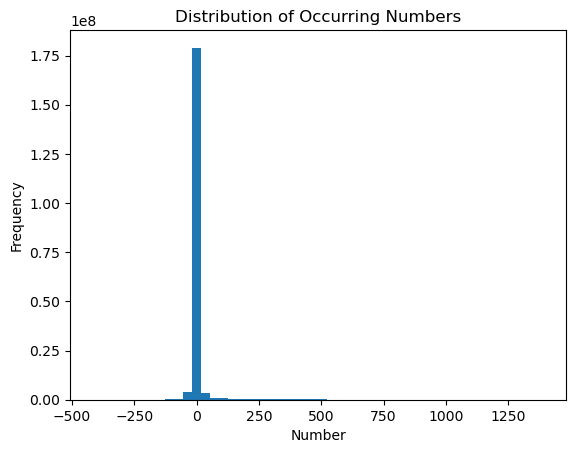

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming your DataFrame is stored in a variable called df

# Flatten the arrays in the DataFrame
flattened_arrays = np.concatenate(df.cap_img.values.flatten())

# Plot the distribution
plt.hist(flattened_arrays, bins=50)
plt.xlabel('Number')
plt.ylabel('Frequency')
plt.title('Distribution of Occurring Numbers')
plt.show()


In [21]:
df.cap_img.map(lambda x : np.min(x)).min()

-416

In [18]:
df.cap_img.map(lambda x : np.max(x)).max()

1392

In [17]:
min_val, max_val = np.min(df.cap_img.iloc[0]), np.max(df.cap_img.iloc[0])
min_val, max_val

(-33, 414)

In [6]:
df.iloc[0]

cap_img       [[0, -1, 0, 1, 2, 0, 3, 3, 3, 3, -1, -1, 9, 3,...
data_id                                                    34.0
depth_img     [[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...
filename                              data_g_65_ 0_00000034.npz
gesture_id                                                 65.0
session_id                                         right_hand_1
subject_id                                                  P05
touch_id                                                    0.0
Name: 0, dtype: object

## Chili data

In [10]:
cap_img = pd.read_csv(new_data+"/Arish_1_UP_100_rawdata.csv",sep=' ')
display(cap_img)
#what is this exactly?
pen_img= pd.read_csv(new_data+"/Arish_1_UP_100_pendata.csv",sep=' ', header=None)
pen_img.head()

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,0,1,2,3,4,5,...,3014,3015,3016,3017,3018,3019,3020,3021,3022,3023
0,1680508053473,1680508053470,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1680508053489,1680508053485,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1680508053506,1680508053505,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1680508053519,1680508053515,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1680508053532,1680508053530,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6302,1680508137815,1680508137815,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6303,1680508137827,1680508137825,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6304,1680508137838,1680508137835,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6305,1680508137851,1680508137850,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,0,1,2,3,4,5,6,7,8,9,10
0,Arish1,4,100,1680508038535,1680508038535,2654,494,640,920,0,0
1,Arish1,4,100,1680508038540,1680508038540,2654,494,640,920,0,0
2,Arish1,4,100,1680508038545,1680508038545,2654,494,640,920,0,0
3,Arish1,4,100,1680508038551,1680508038550,2654,492,640,920,0,0
4,Arish1,4,100,1680508038557,1680508038555,2654,492,640,920,0,0


Concatenate the capacitive image cords

Merge Timestamps is a discretized fixed time interval

In [11]:
pixels= cap_img.iloc[:, -3024:]
cap_img['img'] = pixels.values.tolist()
cap_img = cap_img.drop(pixels.columns, axis=1)
cap_img.head() 

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,img
0,1680508053473,1680508053470,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1680508053489,1680508053485,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1680508053506,1680508053505,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1680508053519,1680508053515,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1680508053532,1680508053530,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [12]:
pixels.iloc[:,1500].unique()

array([  0, 124, 176, 370, 364, 276, 334, 300, 378, 376, 308, 264, 198,
       232, 252, 180, 288, 286, 360, 342, 374, 362, 422, 266, 282, 280,
       310, 358, 322, 386, 368, 406, 302, 150,  50,  40,  72,  86, 332,
       438, 442, 680, 590, 652, 616, 694, 656, 678, 606, 558, 672, 522,
       458, 550, 546, 480, 412, 496, 278,  98,  68,  84, 126,  46,  48,
         6,  20, 494, 596, 366, 182, 340, 488, 538, 474, 524, 594, 470,
       544, 602, 608, 588, 600, 526, 586, 640, 568, 638, 804, 684, 646,
       628, 578, 554, 502, 630, 580, 520, 574, 566, 556, 598, 654, 482,
       610, 604, 452, 576, 552, 614, 518, 506, 414, 430, 248, 250,  80,
        18,   4, 118, 296, 256, 172, 344, 162, 214, 230,  90, 258, 216,
       292])

In [13]:
#no length problem
cap_img[cap_img['img'].apply(lambda x: len(x)) != 3024]

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,img


In [14]:
valid_wacom= pd.read_csv(new_data+"/userarish_2023-04-03_10-09-56_43452_videoframe.csv",sep=',', index_col=0)
display(valid_wacom)
skeleton= pd.read_csv(new_data+"/userarish_2023-04-03_10-10-07_11956_handleap.csv",sep=',', index_col=0)
skeleton.head()

,time,valid_hand
0,1.680508e+09,0
1,1.680508e+09,0
2,1.680508e+09,0
3,1.680508e+09,0
4,1.680508e+09,0
...,...,...
43447,1.680509e+09,0
43448,1.680509e+09,0
43449,1.680509e+09,0
43450,1.680509e+09,0


,Timestamp,wrist_x,wrist_y,wrist_z,Thumb_0_x,Thumb_0_y,Thumb_0_z,Thumb_1_x,Thumb_1_y,Thumb_1_z,...,Pinky_1_z,Pinky_2_x,Pinky_2_y,Pinky_2_z,Pinky_3_x,Pinky_3_y,Pinky_3_z,Pinky_4_x,Pinky_4_y,Pinky_4_z
0,1.680508e+09,-139.203323,274.228577,49.082916,-114.933983,253.419250,30.097525,-114.933983,253.419250,30.097525,...,-1.378431,-79.235779,316.579315,-9.686751,-66.095505,310.570587,-4.683544,-63.091114,302.499756,3.833986
1,1.680508e+09,-140.807953,275.914978,48.604588,-116.763191,254.998688,29.973202,-116.763191,254.998688,29.973202,...,-1.610328,-81.087822,317.742035,-10.036551,-67.429924,312.277679,-5.582808,-63.150959,305.029114,2.546285
2,1.680508e+09,-141.657455,276.928864,48.438431,-117.944008,255.992447,29.780630,-117.944008,255.992447,29.780630,...,-1.542735,-82.366440,318.522095,-10.068500,-68.662849,313.191895,-6.016860,-64.336670,305.981537,1.776773
3,1.680508e+09,-142.424988,277.627655,48.370846,-118.904243,256.690155,29.705805,-118.904243,256.690155,29.705805,...,-1.483135,-83.491470,319.006104,-10.107798,-69.866707,313.695801,-6.286170,-65.547409,306.522583,1.397558
4,1.680508e+09,-143.209824,278.107635,48.447624,-119.784531,257.230042,29.819784,-119.784531,257.230042,29.819784,...,-1.366892,-84.573372,319.315247,-10.042198,-71.030754,313.933380,-6.230742,-66.825378,306.697205,1.491625


valid_hand no true values

In [15]:
valid_wacom.valid_hand.any()

False

Image in report with 25 locations, each finger has 5 positions

In [16]:
skeleton.columns

Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Thumb_4_x', 'Thumb_4_y', 'Thumb_4_z', 'Index_0_x', 'Index_0_y',
       'Index_0_z', 'Index_1_x', 'Index_1_y', 'Index_1_z', 'Index_2_x',
       'Index_2_y', 'Index_2_z', 'Index_3_x', 'Index_3_y', 'Index_3_z',
       'Index_4_x', 'Index_4_y', 'Index_4_z', 'Middle_0_x', 'Middle_0_y',
       'Middle_0_z', 'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x',
       'Middle_2_y', 'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z',
       'Middle_4_x', 'Middle_4_y', 'Middle_4_z', 'Ring_0_x', 'Ring_0_y',
       'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x', 'Ring_2_y',
       'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Ring_4_x', 'Ring_4_y',
       'Ring_4_z', 'Pinky_0_x', 'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x',
       'Pinky_1_y', 'Pinky_1_z'

In [17]:
len(skeleton.columns)

79

In [18]:
valid_ipad= pd.read_csv(new_data+"/userarish_ipad_2023-04-03_10-13-28_49778_videoframe.csv",sep=',',usecols=[1,2])
valid_ipad.head()

,time,valid_hand
0,1.680508e+09,0
1,1.680508e+09,0
2,1.680508e+09,0
3,1.680508e+09,0
4,1.680508e+09,0


same problem for ipad

In [19]:
valid_ipad.valid_hand.any()

False

Trying to run the model

In [20]:
control = id_key[identifier]
df_group = df.groupby([control])[["cap_img","depth_img"]]
g_id = list(df_group.groups.keys())

In [ ]:
depth_err = []
for i in range(len(g_id)):
    test_set = [g_id[i]]
    X_test_cap, Y_test_depth= get_data_splits(df_group,test_set)
    model = get_model(identifier, model_path, test_set)
    Y_out_depth = model.predict(X_test_cap, batch_size=128)
    depth_error = np.mean(abs(Y_test_depth - Y_out_depth[:,:,:,0])) * 255
    depth_err.append(depth_error)
    print("Accuracy", g_id[i],depth_error)
    break


In [ ]:
X_test_cap.shape

(5275, 41, 72)

In [184]:
def prepare_input(df,maxVal=1501):
    input=np.array(df['img'].map(lambda x: np.array(x).reshape(42,72)).tolist())
    input=input[:,:41,:]
    input = input/maxVal
    return input

input=prepare_input(cap_img)
print(input.shape)

(6307, 41, 72)


In [105]:
maxVal = 0
minval = 100000
for i in range(len(input)):
    if maxVal < np.max(input[i]):
        maxVal = np.max(input[i])
    if minval > np.min(input[i]):
        minval = np.min(input[i])
print(maxVal)
print(minval)

1501
0


In [109]:
Y_out_depth=model.predict(input, batch_size=128)

50/50 [==============================] - 3s 54ms/step


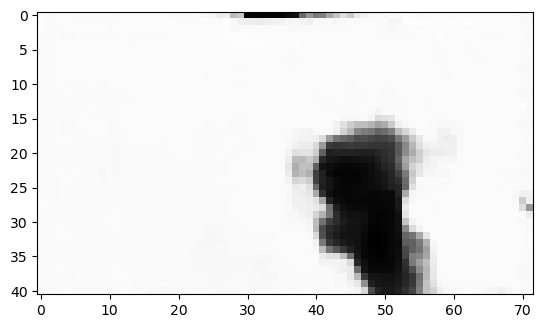

In [110]:
import matplotlib.pyplot as plt

plt.imshow(Y_out_depth[5000], cmap='gray')

There is no more information on data and model thta genrates hand skeleton